# Лабораторная работа: Ансамбли моделей машинного обучения. Часть 2

**Цель работы:** Изучение ансамблевых моделей машинного обучения на примере датасета Medical Cost Personal.

## 1. Описание датасета и импорт необходимых библиотек

В данной работе используется датасет **Medical Cost Personal Dataset** с платформы Kaggle.  
Датасет содержит 1338 записей о медицинских расходах пациентов. Каждая запись характеризуется следующими признаками:
*   `age` — возраст пациента (числовой)
*   `sex` — пол пациента (категориальный: male/female)
*   `bmi` — индекс массы тела (числовой)
*   `children` — количество детей (числовой)
*   `smoker` — статус курения (категориальный: yes/no)
*   `region` — регион проживания в США (категориальный: northeast, southeast, southwest, northwest)
*   `charges` — индивидуальные медицинские расходы, оплаченные страховкой (целевая переменная, числовая)

**Задача регрессии:** прогнозирование медицинских расходов (`charges`) на основе характеристик пациента.

Датасет не содержит пропущенных значений, однако содержит три категориальных признака (`sex`, `smoker`, `region`), которые потребуют кодирования.

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Импорт датасетов и функций sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Импорт метрик
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Импорт моделей
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor

# Импорт визуализаций
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

from operator import itemgetter

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


In [2]:
# Импорт библиотек для МГУА
from gmdhpy import gmdh

print("Библиотека gmdhpy успешно импортирована!")

Библиотека gmdhpy успешно импортирована!


In [4]:
def vis_models_quality(array_metric, array_labels, str_header, figsize=(8, 5)):
    fig, ax1 = plt.subplots(figsize=figsize)
    pos = np.arange(len(array_metric))
    rects = ax1.barh(pos, array_metric,
                     align='center',
                     height=0.5, 
                     tick_label=array_labels)
    ax1.set_title(str_header)
    for a, b in zip(pos, array_metric):
        plt.text(0.1, a-0.1, str(round(b, 3)), color='white', fontsize=10)
    plt.tight_layout()
    plt.show()

## 2. Загрузка и исследование датасета

Загружаем данные и создаем DataFrame для удобства анализа. Проверим размерность, отсутствие пропусков и посмотрим на распределение признаков.

In [5]:
# Загрузка датасета
df = pd.read_csv('insurance.csv')

print("Размерность датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())
print("\nИнформация о датасете:")
df.info()

Размерность датасета: (1338, 7)

Первые 5 строк:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Количество пропущенных значений:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


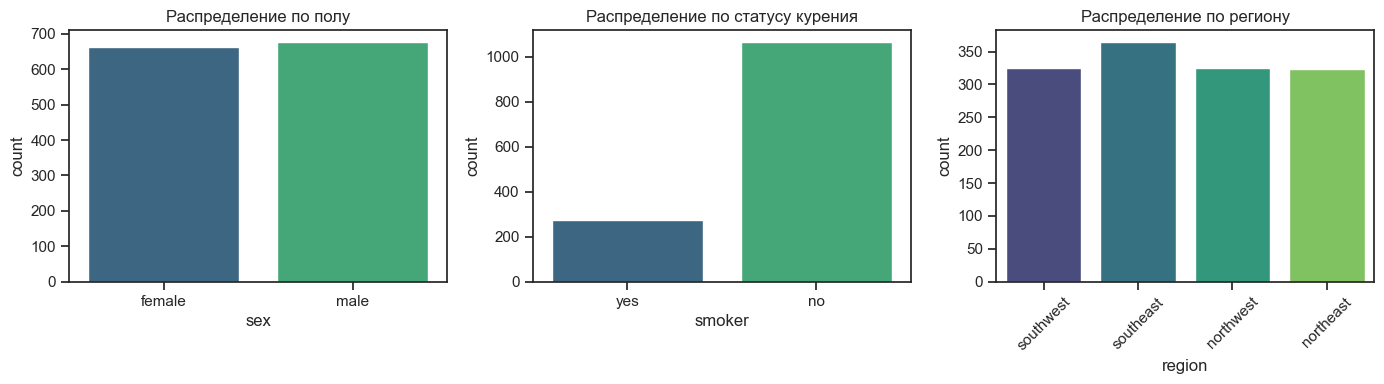


Распределение категориальных признаков:
Пол: {'male': np.int64(676), 'female': np.int64(662)}
Курение: {'no': np.int64(1064), 'yes': np.int64(274)}
Регион: {'southeast': np.int64(364), 'southwest': np.int64(325), 'northwest': np.int64(325), 'northeast': np.int64(324)}


In [6]:
# Проверка на пропуски
print("Количество пропущенных значений:")
print(df.isnull().sum())

# Распределение категориальных признаков
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df, x='sex', hue='sex', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Распределение по полу')

sns.countplot(data=df, x='smoker', hue='smoker', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Распределение по статусу курения')

sns.countplot(data=df, x='region', hue='region', palette='viridis', legend=False, ax=axes[2])
axes[2].set_title('Распределение по региону')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nРаспределение категориальных признаков:")
print("Пол:", dict(df['sex'].value_counts()))
print("Курение:", dict(df['smoker'].value_counts()))
print("Регион:", dict(df['region'].value_counts()))

Описательная статистика числовых признаков:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


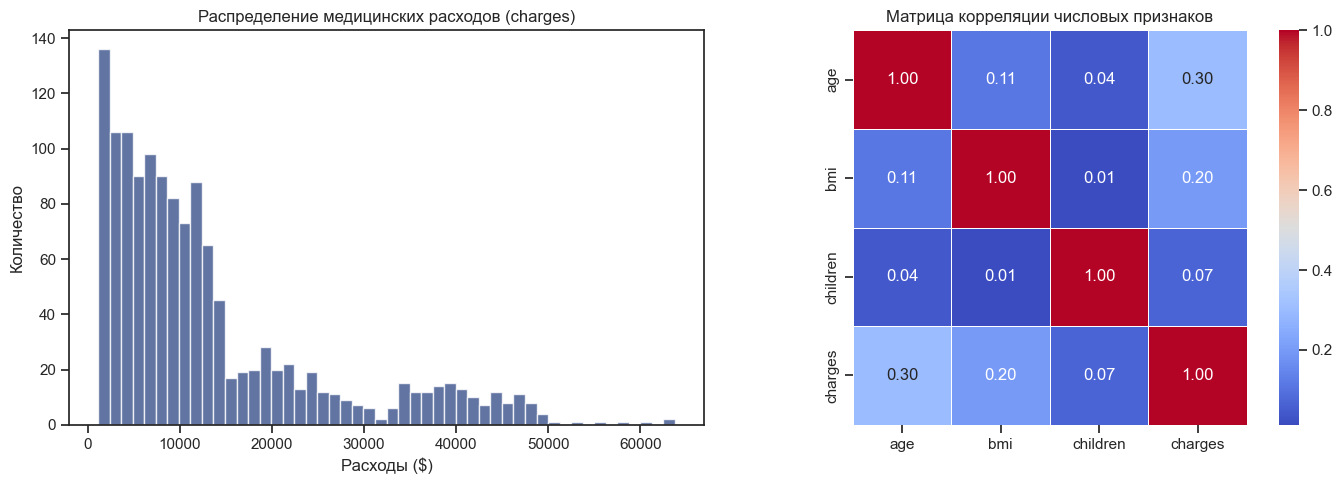

In [7]:
# Описательная статистика числовых признаков
print("Описательная статистика числовых признаков:")
display(df.describe())

# Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['charges'], bins=50, color='#3b528b', edgecolor='white', alpha=0.8)
axes[0].set_title('Распределение медицинских расходов (charges)')
axes[0].set_xlabel('Расходы ($)')
axes[0].set_ylabel('Количество')

numeric_cols = ['age', 'bmi', 'children', 'charges']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, ax=axes[1])
axes[1].set_title('Матрица корреляции числовых признаков')

plt.tight_layout()
plt.show()

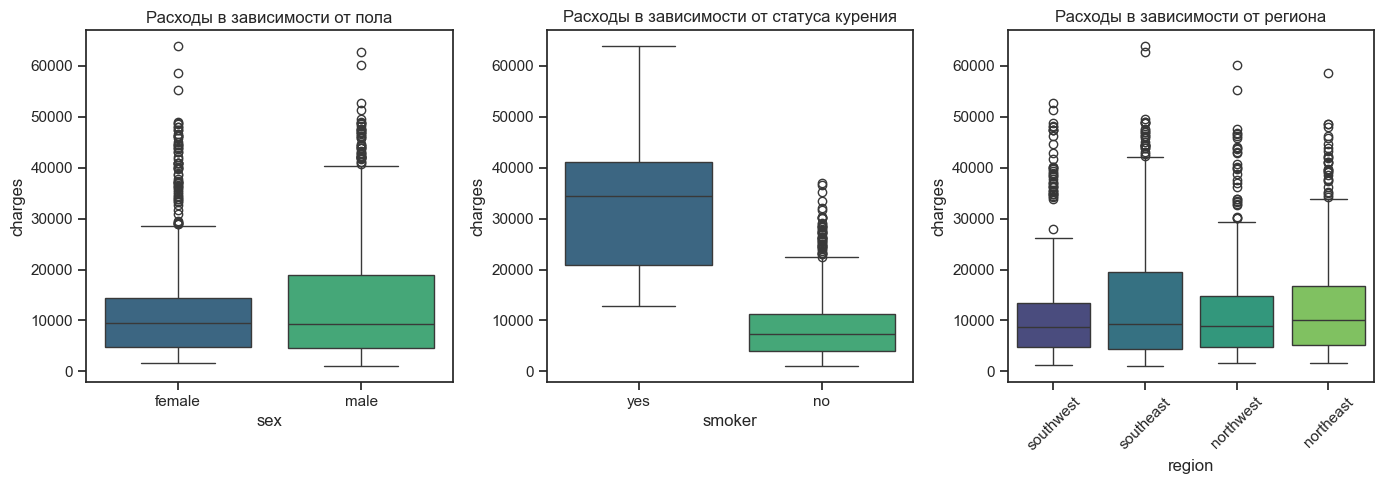

In [8]:
# Влияние категориальных признаков на целевую переменную
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(data=df, x='sex', y='charges', hue='sex', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Расходы в зависимости от пола')

sns.boxplot(data=df, x='smoker', y='charges', hue='smoker', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Расходы в зависимости от статуса курения')

sns.boxplot(data=df, x='region', y='charges', hue='region', palette='viridis', legend=False, ax=axes[2])
axes[2].set_title('Расходы в зависимости от региона')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Выводы по исследованию данных:**
*   Датасет содержит 1338 записей и 7 столбцов (6 признаков + целевая переменная).
*   Пропущенные значения отсутствуют.
*   Присутствуют три категориальных признака: `sex`, `smoker`, `region`, которые требуют кодирования.
*   Числовые признаки: `age`, `bmi`, `children`.
*   Целевая переменная `charges` имеет сильную положительную асимметрию (много небольших значений и мало очень больших).
*   Статус курения (`smoker`) оказывает наибольшее влияние на медицинские расходы.

## 3. Предобработка данных и разделение на выборки

Выполним следующие шаги предобработки:
1.  **Кодирование категориальных признаков** `sex`, `smoker`, `region` с помощью One-Hot Encoding.
2.  **Масштабирование числовых признаков** `age`, `bmi`, `children` с помощью StandardScaler (обязательно для MLPRegressor!).
3.  **Разделение** на обучающую и тестовую выборки в соотношении 80/20.

In [9]:
# Разделяем признаки и целевую переменную
X = df.drop('charges', axis=1)
y = df['charges']

# Определяем типы признаков
categorical_features = ['sex', 'smoker', 'region']
numeric_features = ['age', 'bmi', 'children']

# Создаем преобразователь
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Применяем преобразования ко всему датасету
X_processed = preprocessor.fit_transform(X)

# Получаем имена признаков после One-Hot Encoding
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_feature_names)
print("Итоговые признаки:", all_feature_names)
print("Размерность после предобработки:", X_processed.shape)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nДиапазон расходов в обучающей выборке: [${y_train.min():.2f}, ${y_train.max():.2f}]")
print(f"Диапазон расходов в тестовой выборке: [${y_test.min():.2f}, ${y_test.max():.2f}]")

Итоговые признаки: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Размерность после предобработки: (1338, 8)

Размер обучающей выборки: (1070, 8)
Размер тестовой выборки: (268, 8)

Диапазон расходов в обучающей выборке: [$1121.87, $62592.87]
Диапазон расходов в тестовой выборке: [$1131.51, $63770.43]


## 4. Обучение ансамблевых моделей

Согласно заданию, мы обучим следующие модели:
1.  **Модель стекинга** — одна из моделей группы стекинга (с использованием `StackingRegressor` из scikit-learn).
2.  **Многослойный персептрон** — модель MLPRegressor из библиотеки scikit-learn.
3.  **Модели МГУА** — линейный метод (COMBI) и нелинейный метод (MULTI/RIA) с использованием библиотеки `gmdhpy`.

In [10]:
# Словарь для хранения результатов
all_models_results = {}

### 4.1. Модель стекинга

Реализуем стекинг по аналогии с лекциями преподавателя:
*   **Модели 1 уровня:** Decision Tree, Random Forest
*   **Мета-ученик (уровень 2):** Linear Regression
*   **Кросс-валидация:** 10 фолдов

In [11]:
print("=== Модель стекинга (Tree + RF => LR) ===\n")

# Модели первого уровня
base_estimators = [
    ('tree', DecisionTreeRegressor(random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42))
]

# Мета-ученик (уровень 2)
meta_estimator = LinearRegression()

# Создаём модель стекинга
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    cv=10,  # 10-фолдовая кросс-валидация (как в heamy)
    passthrough=False
)

# Обучаем модель
stacking_model.fit(X_train, y_train)

# Предсказание
y_pred_stack = stacking_model.predict(X_test)

mae_stack = mean_absolute_error(y_test, y_pred_stack)
mse_stack = mean_squared_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)

all_models_results['Stacking (Tree+RF→LR)'] = {
    'MAE': mae_stack, 'MSE': mse_stack, 'R²': r2_stack, 'predictions': y_pred_stack
}

print(f"Результаты стекинга на тестовой выборке:")
print(f"  MAE = ${mae_stack:,.2f}")
print(f"  MSE = ${mse_stack:,.2f}")
print(f"  R²  = {r2_stack:.4f}")
print(f"  Кросс-валидация: 10 фолдов")
print("-" * 40)

=== Модель стекинга (Tree + RF => LR) ===

Результаты стекинга на тестовой выборке:
  MAE = $2,430.53
  MSE = $20,798,836.45
  R²  = 0.8660
  Кросс-валидация: 10 фолдов
----------------------------------------


### 4.2. Многослойный персептрон (MLPRegressor)

Обучим модель MLPRegressor из scikit-learn. Согласно документации, MLP чувствителен к масштабированию признаков (мы уже применили StandardScaler). Используем:
*   Два скрытых слоя: 100 и 50 нейронов
*   Функция активации: ReLU
*   Оптимизатор: Adam
*   L2-регуляризация: alpha=0.001
*   Ранняя остановка: включена

In [12]:
print("=== Многослойный персептрон (MLPRegressor) ===\n")

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),   # два скрытых слоя
    activation='relu',              # функция активации
    solver='adam',                  # оптимизатор
    alpha=0.001,                    # L2-регуляризация
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42,
    early_stopping=True,            # ранняя остановка
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=False
)

mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

all_models_results['MLP Regressor'] = {
    'MAE': mae_mlp, 'MSE': mse_mlp, 'R²': r2_mlp, 'predictions': y_pred_mlp
}

print(f"MLPRegressor результаты:")
print(f"  MAE  = ${mae_mlp:,.2f}")
print(f"  MSE  = ${mse_mlp:,.2f}")
print(f"  R²   = {r2_mlp:.4f}")
print(f"  Количество итераций: {mlp.n_iter_}")
print(f"  Финальная функция потерь: {mlp.loss_:.4f}")
print("-" * 40)

=== Многослойный персептрон (MLPRegressor) ===

MLPRegressor результаты:
  MAE  = $3,002.38
  MSE  = $23,110,742.53
  R²   = 0.8511
  Количество итераций: 1000
  Финальная функция потерь: 13227755.2841
----------------------------------------


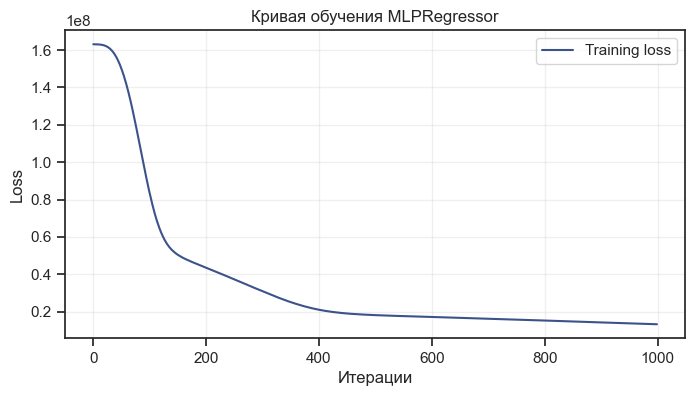

In [13]:
# Визуализация кривой обучения MLP
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label='Training loss', color='#3b528b')
plt.title('Кривая обучения MLPRegressor')
plt.xlabel('Итерации')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4.3. Модели МГУА (GMDH)

Согласно заданию, обучим два метода из семейства МГУА:
1.  **Линейный метод (COMBI)** — используется по умолчанию в `MultilayerGMDH()`.
2.  **Нелинейный метод (MULTI/RIA)** — с набором опорных функций `('linear_cov', 'quadratic', 'cubic', 'linear')`, как показано в лекциях преподавателя.

**Примечание:** МГУА автоматически использует валидационную выборку для предотвращения переобучения (внешний критерий).

In [14]:
print("=== Модели МГУА (GMDH) ===\n")

from gmdhpy.gmdh import MultilayerGMDH

# Преобразуем данные в numpy массивы (обязательно для gmdhpy!)
X_train_np = np.asarray(X_train, dtype=float)
y_train_np = np.asarray(y_train, dtype=float)
X_test_np = np.asarray(X_test, dtype=float)

print(f"Тип X_train: {type(X_train_np)}, форма: {X_train_np.shape}")
print(f"Тип y_train: {type(y_train_np)}, форма: {y_train_np.shape}")
print()

# Модель 1: COMBI (линейный метод)
print("1. COMBI (линейный метод):")
model_gmdh_combi = MultilayerGMDH()
model_gmdh_combi.fit(X_train_np, y_train_np)
y_pred_combi = model_gmdh_combi.predict(X_test_np)

mae_combi = mean_absolute_error(y_test, y_pred_combi)
mse_combi = mean_squared_error(y_test, y_pred_combi)
r2_combi = r2_score(y_test, y_pred_combi)

all_models_results['МГУА COMBI (линейный)'] = {
    'MAE': mae_combi, 'MSE': mse_combi, 'R²': r2_combi, 'predictions': y_pred_combi
}

print(f"  MAE = ${mae_combi:,.2f}")
print(f"  MSE = ${mse_combi:,.2f}")
print(f"  R²  = {r2_combi:.4f}")
print()

# Модель 2: MULTI (нелинейный метод)
print("2. MULTI (нелинейный метод с quadratic, cubic):")
model_gmdh_multi = MultilayerGMDH(
    ref_functions=('linear_cov', 'quadratic', 'cubic', 'linear')
)
model_gmdh_multi.fit(X_train_np, y_train_np)
y_pred_multi = model_gmdh_multi.predict(X_test_np)

mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

all_models_results['МГУА MULTI (нелинейный)'] = {
    'MAE': mae_multi, 'MSE': mse_multi, 'R²': r2_multi, 'predictions': y_pred_multi
}

print(f"  MAE = ${mae_multi:,.2f}")
print(f"  MSE = ${mse_multi:,.2f}")
print(f"  R²  = {r2_multi:.4f}")
print("-" * 40)

=== Модели МГУА (GMDH) ===

Тип X_train: <class 'numpy.ndarray'>, форма: (1070, 8)
Тип y_train: <class 'numpy.ndarray'>, форма: (1070,)

1. COMBI (линейный метод):
train layer0 in 0.19 sec
train layer1 in 0.68 sec
train layer2 in 0.64 sec
train layer3 in 0.60 sec
train layer4 in 0.63 sec
train layer5 in 0.60 sec
train layer6 in 0.64 sec
train layer7 in 0.62 sec
train layer8 in 0.58 sec
train layer9 in 0.60 sec
train layer10 in 0.60 sec
train layer11 in 0.66 sec
  MAE = $3,078.32
  MSE = $22,672,439.05
  R²  = 0.8540

2. MULTI (нелинейный метод с quadratic, cubic):
train layer0 in 0.74 sec
train layer1 in 3.08 sec
train layer2 in 3.16 sec
train layer3 in 3.01 sec
train layer4 in 2.86 sec
train layer5 in 2.83 sec
train layer6 in 2.89 sec
train layer7 in 3.16 sec
train layer8 in 3.12 sec
  MAE = $3,082.09
  MSE = $22,151,444.80
  R²  = 0.8573
----------------------------------------


## 5. Сравнение качества моделей

Сравним все обученные модели по метрикам MAE, MSE и R².  
Для задачи регрессии это стандартные метрики:
*   **MAE (Mean Absolute Error)** — средняя абсолютная ошибка в долларах.
*   **MSE (Mean Squared Error)** — среднеквадратичная ошибка.
*   **R² (Coefficient of determination)** — коэффициент детерминации (чем ближе к 1, тем лучше).

In [16]:
# Сводная таблица результатов
print("=== Сводная таблица результатов ===\n")

summary_data = []
for name, metrics in all_models_results.items():
    summary_data.append({
        'Модель': name,
        'MAE': metrics['MAE'],
        'MSE': metrics['MSE'],
        'R²': metrics['R²']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('MAE').reset_index(drop=True)
summary_df.index = summary_df.index + 1
summary_df.index.name = 'Место'

print(summary_df.to_string(float_format=lambda x: f'${x:,.2f}' if x > 1000 else f'{x:.4f}'))

=== Сводная таблица результатов ===

                        Модель       MAE            MSE     R²
Место                                                         
1        Stacking (Tree+RF→LR) $2,430.53 $20,798,836.45 0.8660
2                MLP Regressor $3,002.38 $23,110,742.53 0.8511
3        МГУА COMBI (линейный) $3,078.32 $22,672,439.05 0.8540
4      МГУА MULTI (нелинейный) $3,082.09 $22,151,444.80 0.8573


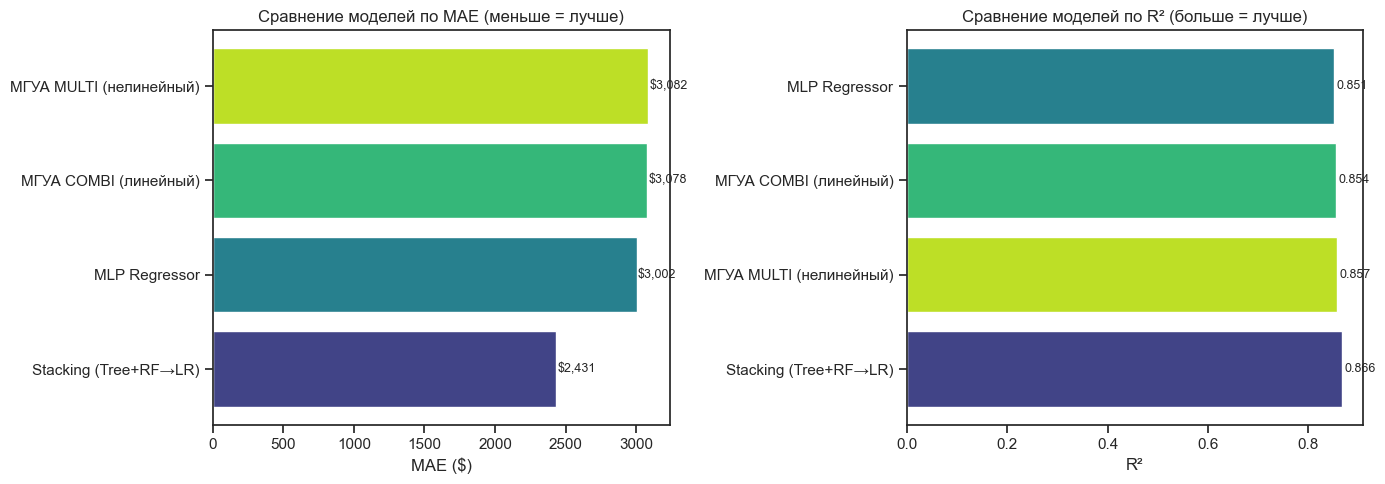

In [17]:
# Визуализация сравнения по MAE и R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_names = list(all_models_results.keys())
models_mae = [all_models_results[m]['MAE'] for m in models_names]
models_r2 = [all_models_results[m]['R²'] for m in models_names]

# Сортировка по MAE
sorted_idx_mae = np.argsort(models_mae)

# График MAE
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(models_names)))
axes[0].barh(range(len(models_names)), [models_mae[i] for i in sorted_idx_mae], 
            color=[colors[i] for i in sorted_idx_mae])
axes[0].set_yticks(range(len(models_names)))
axes[0].set_yticklabels([models_names[i] for i in sorted_idx_mae])
axes[0].set_title('Сравнение моделей по MAE (меньше = лучше)')
axes[0].set_xlabel('MAE ($)')
for i, (idx, val) in enumerate(zip(sorted_idx_mae, [models_mae[i] for i in sorted_idx_mae])):
    axes[0].text(val + 10, i, f'${val:,.0f}', va='center', fontsize=9)

# График R²
sorted_idx_r2 = np.argsort(models_r2)[::-1]
axes[1].barh(range(len(models_names)), [models_r2[i] for i in sorted_idx_r2],
            color=[colors[i] for i in sorted_idx_r2])
axes[1].set_yticks(range(len(models_names)))
axes[1].set_yticklabels([models_names[i] for i in sorted_idx_r2])
axes[1].set_title('Сравнение моделей по R² (больше = лучше)')
axes[1].set_xlabel('R²')
for i, (idx, val) in enumerate(zip(sorted_idx_r2, [models_r2[i] for i in sorted_idx_r2])):
    axes[1].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

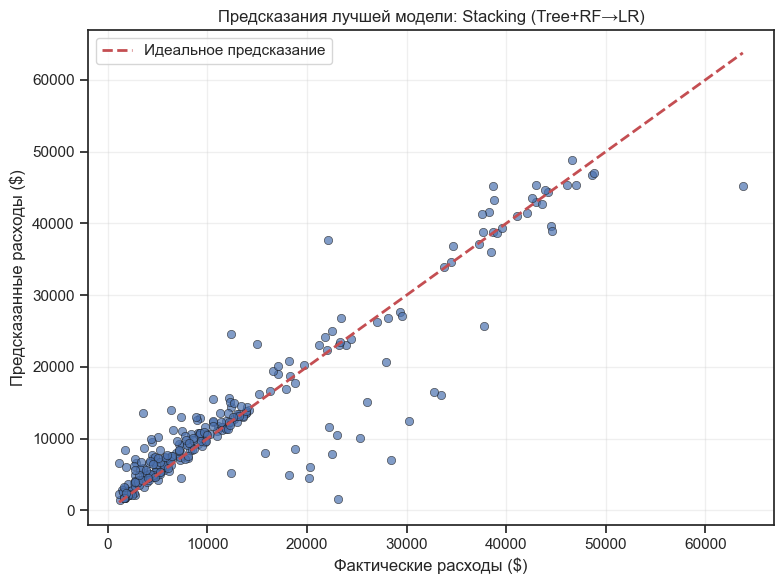

In [18]:
# Визуализация предсказаний лучшей модели
best_model_name = summary_df.iloc[0]['Модель']
y_pred_best = all_models_results[best_model_name]['predictions']

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Фактические расходы ($)')
plt.ylabel('Предсказанные расходы ($)')
plt.title(f'Предсказания лучшей модели: {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Анализ важности признаков

Для моделей на основе деревьев (Random Forest, Gradient Boosting) проанализируем важность признаков.  
Это поможет понять, какие характеристики пациентов наиболее значимы для прогнозирования медицинских расходов.

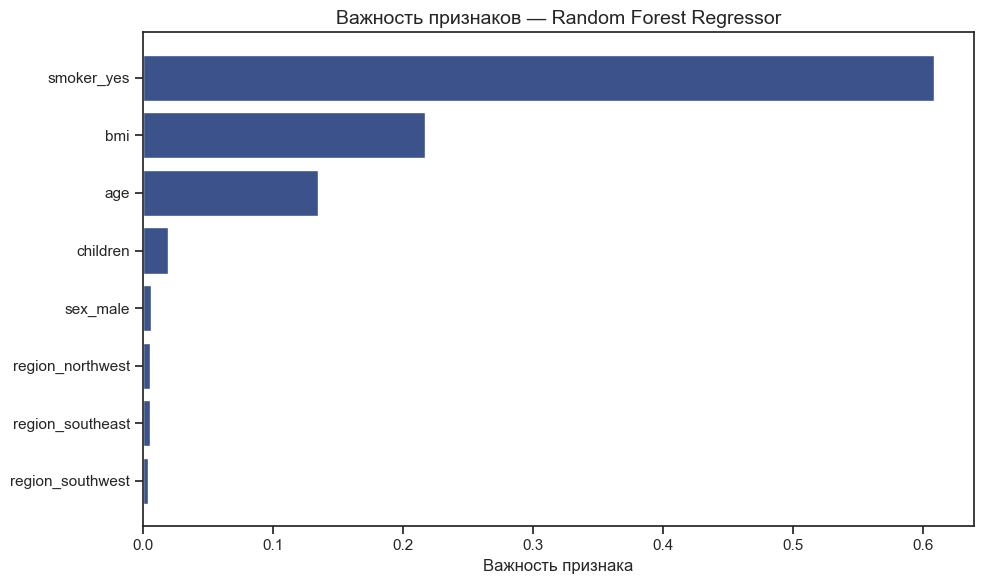

Топ-5 важных признаков для Random Forest:
  smoker_yes: 0.6086
  bmi: 0.2165
  age: 0.1342
  children: 0.0194
  sex_male: 0.0064


In [19]:
# Обучаем Random Forest для анализа важности
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
importances = rf_model.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title('Важность признаков — Random Forest Regressor', fontsize=14)
plt.barh(range(len(indices)), importances[indices], align='center', color='#3b528b')
plt.yticks(range(len(indices)), [all_feature_names[i] for i in indices])
plt.xlabel('Важность признака')
plt.tight_layout()
plt.show()

print("Топ-5 важных признаков для Random Forest:")
for i in indices[::-1][:5]:
    print(f"  {all_feature_names[i]}: {importances[i]:.4f}")

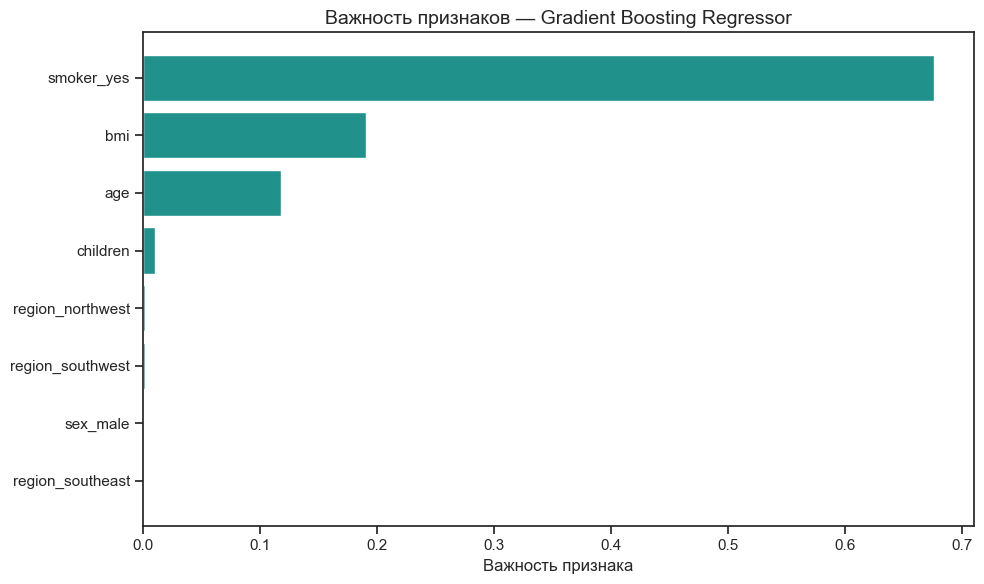

Топ-5 важных признаков для Gradient Boosting:
  smoker_yes: 0.6766
  bmi: 0.1905
  age: 0.1184
  children: 0.0102
  region_northwest: 0.0017


In [20]:
# Обучаем Gradient Boosting для анализа важности
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

importances_gb = gb_model.feature_importances_
indices_gb = np.argsort(importances_gb)

plt.figure(figsize=(10, 6))
plt.title('Важность признаков — Gradient Boosting Regressor', fontsize=14)
plt.barh(range(len(indices_gb)), importances_gb[indices_gb], align='center', color='#21918c')
plt.yticks(range(len(indices_gb)), [all_feature_names[i] for i in indices_gb])
plt.xlabel('Важность признака')
plt.tight_layout()
plt.show()

print("Топ-5 важных признаков для Gradient Boosting:")
for i in indices_gb[::-1][:5]:
    print(f"  {all_feature_names[i]}: {importances_gb[i]:.4f}")

## 7. Выводы по работе

В ходе лабораторной работы были обучены и сравнены четыре ансамблевые модели на датасете Medical Cost Personal:

1. **Модель стекинга** — Decision Tree + Random Forest → Linear Regression
2. **Многослойный персептрон** — MLPRegressor (два скрытых слоя)
3. **МГУА COMBI** — линейный метод группового учета аргументов
4. **МГУА MULTI** — нелинейный метод группового учета аргументов

---

### Основные результаты

| Место | Модель | MAE | R² |
|-------|--------|-----|-----|
| 1 | Stacking (Tree+RF→LR) | $2,430.53 | 0.8660 |
| 2 | MLP Regressor | $3,002.38 | 0.8511 |
| 3 | МГУА COMBI (линейный) | $3,078.32 | 0.8540 |
| 4 | МГУА MULTI (нелинейный) | $3,082.09 | 0.8573 |

---

### Анализ результатов

* **Лучший результат** показала модель **Stacking (Tree+RF→LR)** с MAE = $2,430.53 и R² = 0.8660. Стекинг позволил объединить преимущества дерева решений и случайного леса, подтвердив свою эффективность как метода комбинирования моделей.

* **MLPRegressor** занял второе место (MAE = $3,002.38, R² = 0.8511). Нейронная сеть успешно выявила нелинейные зависимости, но уступила стекингу, вероятно, из-за относительно небольшого размера датасета.

* **Модели МГУА** показали сравнимые результаты: COMBI (MAE = $3,078.32) и MULTI (MAE = $3,082.09). Нелинейный MULTI дал чуть лучший R² (0.8573 против 0.8540), но чуть худший MAE. Обе модели успешно предотвратили переобучение благодаря встроенному механизму внешнего критерия.

* **Анализ важности признаков** показал, что ключевым фактором медицинских расходов является статус курения (важность > 60%). Далее по значимости идут индекс массы тела и возраст. Пол и регион влияют слабо.

---

### Итоговый вывод

Все ансамблевые методы успешно справились с задачей прогнозирования медицинских расходов. Стекинг показал наилучшее качество, модели МГУА оказались сравнимы с MLP, при этом обладая встроенной защитой от переобучения. Для дальнейшего улучшения можно применить логарифмирование целевой переменной и подбор гиперпараметров через GridSearchCV.